# ADS 509 Group 4 Final Project: Recipes Classification

## Jeremiah Fa'atiliga, Ravita Kartawinata, Sowmiya Kanmani Maruthavanan

## Importing Packages

In [1]:
import os
import requests
import random
import time
from bs4 import BeautifulSoup
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from string import punctuation
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import defaultdict, Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
import pyLDAvis
import pyLDAvis.lda_model
import pyLDAvis.gensim_models
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.nmf import Nmf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore")

c:\Users\sowmi\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\__init__.py:30: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils as _distutils


## Webscrapping from allrecipes.com

In [3]:
start = time.time()

# Scrapping from Index (meal, ingredients, cuisine)
base_url = "https://www.allrecipes.com/ingredients-a-z-6740416/"

# Get main url
def get_main_ingredients(base_url):
    response = requests.get(base_url)
    time.sleep(5)
    
    soup = BeautifulSoup(response.content, 'html.parser')

    ingredients = []
    for link in soup.find_all('a', class_='mntl-link-list__link'):
        url = link.get('href')
        # print(f"url: {url}\n")
        
        path_parts = url.split('/')
        category = ''
        subcategory = ''
        # read category and subcategory if there is ingredients in the url  
        if 'ingredients' in path_parts:
            # Find the word 'ingredient' to get to category and subcategory
            category_index = path_parts.index('ingredients') + 1
            category = path_parts[category_index]
            subcategory = path_parts[category_index + 1] if category_index + 1 < len(path_parts) else ''
        else:
            category = path_parts[5]
            subcategory = path_parts[6] if len(path_parts) > 6 else ''

        ingredients.append((url, category, subcategory))
    
    return ingredients

# Get recipe links for a given ingredient
def get_recipe_links(ingredient_url):
    response = requests.get(ingredient_url)
    time.sleep(5)
    
    soup = BeautifulSoup(response.content, 'html.parser')

    recipe_links = []
    # get the link from the tile/ card class
    for link in soup.find_all('a', class_='mntl-card-list-items'):
        recipe_links.append(link.get('href'))
        
    return recipe_links

def get_recipe_content(recipe_url):
    try:
        response = requests.get(recipe_url)
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # Check if the title is available
        title_tag = soup.find('h1', class_='article-heading')
        if not title_tag:
            print(f"Skipping {recipe_url}: No title found.")
            return None, None
        title = title_tag.text.strip()
        
        # Extract the article subheading
        header_div = soup.find('div', id='article-header--recipe_1-0')
        if not header_div:
            print(f"Skipping {recipe_url}: No article header found.")
            return None, None
            
        subheading = header_div.find('p', class_='article-subheading')
        subheading_text = subheading.text.strip() if subheading else "No subheading available"
        content_sections = [subheading_text]
        
        # Set the sections for various recipe components
        sections = {
            'mm-recipes-intro__content_1-0': 'comp mm-recipes-intro__content mntl-sc-page mntl-block',
            'mm-recipes-structured-ingredients_1-0': 'comp mm-recipes-structured-ingredients',
            'mm-recipes-steps__content_1-0': 'comp mm-recipes-steps mntl-block',
            'mm-recipes-details_1-0': 'mm-recipes-details__item',
            'mm-recipes-nutrition-facts_1-0': 'comp mm-recipes-nutrition-facts mntl-block',
        }
        
        for section_id, section_class in sections.items():
            section = soup.find('div', id=section_id)
            if section:
                if section_id == 'mm-recipes-structured-ingredients_1-0':
                    
                    # Extract ingredients List
                    ingredients_list = section.find('ul', class_='mm-recipes-structured-ingredients__list')
                    if ingredients_list:
                        content_sections.append("Ingredients:")
                        for item in ingredients_list.find_all('li', class_='mm-recipes-structured-ingredients__list-item'):
                            ingredient_text = item.get_text(separator=' ').strip()
                            content_sections.append(ingredient_text)
                            
                elif section_id == 'mm-recipes-steps__content_1-0':
                    # Extract directions
                    paragraphs = section.find_all('p', class_='comp mntl-sc-block mntl-sc-block-html')
                    if paragraphs:
                        content_sections.append("Directions:")
                        for p in paragraphs:
                            content_sections.append(p.get_text(separator=' ').strip())
                            
                elif section_id == 'mm-recipes-nutrition-facts-summary_1-0':
                    # Extract nutrition table
                    nutrition_facts = []
                    nutrition_table = section.find('table', class_='mm-recipes-nutrition-facts-summary__table')
                    if nutrition_table:
                        rows = nutrition_table.find_all('tr')
                        for row in rows:
                            cells = row.find_all('td')
                            if len(cells) == 2:
                                nutrient_value = cells[0].text.strip()
                                nutrient_name = cells[1].text.strip()
                                nutrition_facts.append(f"{nutrient_name}: {nutrient_value}")
                        content_sections.append("Nutrition Facts:")
                        content_sections.extend(nutrition_facts)
                else:
                    items = section.find_all('div', class_=section_class)
                    if items:
                        for item in items:
                            content_sections.append(item.text.strip())
                    else:
                        content_sections.append(section.text.strip())
            else:
                print(f"Skipping section {section_id} for {recipe_url} as it was not found.")
                continue
        return title, content_sections
    except Exception as e:
        print(f"An error occurred while processing {recipe_url}: {e}")
        return None, None

# Save recipe to file
def save_recipe(title, content, category, subcategory):  
    safe_title = "".join(x for x in title if x.isalnum() or x in (" ", "_")).strip().replace(" ", "_")
    file_path = os.path.join('allrecipes', f"{safe_title}.txt")

    # Write content to txt file
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(f"Category: {category}\n") 
        f.write(f"SubCategory: {subcategory}\n\n") 
        f.write(f"Title: {title}\n\n")
        f.write(f"Description:\n")
        for section in content:
            f.write(section + "\n\n")
    
    print(f"Saved recipe: {file_path}")

# Main scraping logic
def main():
    # overwrite and create allrecipes folder
    if os.path.exists('allrecipes'):
        shutil.rmtree('allrecipes')  

    os.makedirs('allrecipes')

    ingredients = get_main_ingredients(base_url)
    total_saved_recipes = 0  
    
    for ingredient, category, subcategory in ingredients: 
        recipe_links = get_recipe_links(ingredient)
        
        for recipe in recipe_links:
            title, content = get_recipe_content(recipe)
            if title and content:  
                save_recipe(title, content, category, subcategory) 
                

if __name__ == "__main__":
     main()


Saved recipe: allrecipes\Almond_Flour_Bread.txt
Saved recipe: allrecipes\Spicy_GlutenFree_Chicken_and_Cheddar_Waffles_with_BlackberryMaple_Syrup.txt
Saved recipe: allrecipes\Quick_Almond_Flour_Pancakes.txt
Saved recipe: allrecipes\90Second_Keto_Bread_in_a_Mug.txt
Saved recipe: allrecipes\Macarons_French_Macaroons.txt
Saved recipe: allrecipes\Chaffles_with_Almond_Flour.txt
Saved recipe: allrecipes\Almond_FlourBlueberry_Muffins.txt
Saved recipe: allrecipes\Almond_Flour_Waffles.txt
Saved recipe: allrecipes\Best_Keto_Bread.txt
Saved recipe: allrecipes\LowCarb_Almond_Cinnamon_Butter_Cookies.txt
Saved recipe: allrecipes\Almond_Flour_Banana_Bread.txt
Saved recipe: allrecipes\Whole30_Banana_Bread_Drop_Muffins.txt
Saved recipe: allrecipes\Bread_Machine_Almond_Bread.txt
Saved recipe: allrecipes\Keto_Fathead_Bread.txt
Saved recipe: allrecipes\Air_Fryer_Keto_Pork_Chops.txt
Saved recipe: allrecipes\Almond_Meal_Pancakes.txt
Saved recipe: allrecipes\Battenburg_Cake.txt
Saved recipe: allrecipes\French

### Read webscrapped files

In [2]:
# Function to find directory
def find_directory_path(target_dir, start_path='.') :
    
    for root, dirs, files in os.walk(start_path) :
        if target_dir in dirs :
            path = os.path.join(root, target_dir)
            
    return path

In [3]:
recipes_folder = "allrecipes"
recipes_folder_path = find_directory_path(recipes_folder)

In [4]:
# Dictionary to hold recipe contents
recipe_dictionary = {
    'Category': [],
    'SubCategory': [],
    'Title': [],
    'Description': [],
    'Ingredients': [],
    'Directions': [],
    'Prep Time': [],
    'Cook Time': [],
    'Total Time': [],
    'Servings': [],
    'Calories': [],
    'Fat': [],
    'Carbs': [],
    'Protein': []
}

# Iterate through each .txt file
recipes_folder = 'allrecipes/'
# Iterate through each .txt file
for recipe_file in os.listdir(recipes_folder):
    if recipe_file.endswith('.txt'):
        with open(os.path.join(recipes_folder, recipe_file), 'r', encoding='utf-8') as f:
            content = f.read()

        # Extract title, category, subcategory and sections
        category = content.split('\n')[0].replace('Category: ', '').strip()
        subcategory = content.split('\n')[1].replace('SubCategory: ', '').strip()
        title = content.split('\n')[3].replace('Title: ', '').strip()

        # Split the content into sections
        sections = content.split('\n\n')

        # Regex to capture servings line
        servings_pattern = re.compile(r'Original recipe \(1X\) yields (.+?) servings', re.IGNORECASE)
        
        # Initialize placeholders for values
        description = 'Not available'
        ingredients = []
        directions = []
        prep_time = 'No Prep Time'
        cook_time = 'No Cook Time'
        total_time = 'No Total Time'
        serving = 'No Servings'
        calories = 'Not available'
        fat = 'Not available'
        carbs = 'Not available'
        protein = 'Not available'
        
        # Flags for capturing ingredients and directions
        ingre_capturing = False
        direction_capturing = False

        # read sections
        for section in sections:
            section_lower = section.lower()

            # Detect and capture servings
            servings_match = servings_pattern.search(section)
            if servings_match:
                serving = f"{servings_match.group(1)} servings"
                ingre_capturing = True
                continue

            # Detect sections and update flags
            if 'Ingredients:' in section:
                ingre_capturing = True
                continue 
            elif 'Directions:' in section:
                ingre_capturing = False
                direction_capturing = True
                continue
            elif 'Description:' in section:
                description = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'prep time' in section_lower:
                direction_capturing = False
                prep_time = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'cook time' in section_lower:
                cook_time = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'total time' in section_lower:
                total_time = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'servings' in section_lower:
                serving = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            
            elif 'calories' in section_lower:
                calories = ''.join(filter(str.isdigit, section))
            elif 'fat' in section_lower:
                fat = section.split('\n')[1].strip() if len(section.split('\n')) > 1 else 'Not available'
            elif 'carbs' in section_lower:
                carbs = section.split('\n')[1].strip() if len(section.split('\n')) > 1 else 'Not available'
            elif 'protein' in section_lower:
                protein = ''.join(filter(str.isdigit, section))
                
            # Capture ingredients and directions
            elif ingre_capturing and section.strip():
                # Ignore any lines that look like "1x, 2x, 4x..." or error messages
                if re.match(r'^\d+x$', section.strip()) or 'oops' in section.lower():
                    continue
                ingredients.append(section.strip())
            elif direction_capturing and section.strip():
                directions.append(section.strip())
                
        # Finalize the cleaning
        cleaned_ingredients = [ingredient for ingredient in ingredients if not re.search(r'Original recipe \(1X\) yields', ingredient)]

        # Append to the dictionary
        recipe_dictionary['Category'].append(category)
        recipe_dictionary['SubCategory'].append(subcategory)
        recipe_dictionary['Title'].append(title)
        recipe_dictionary['Description'].append(description)
        recipe_dictionary['Ingredients'].append(', '.join(cleaned_ingredients))
        recipe_dictionary['Directions'].append(', '.join(directions))
        recipe_dictionary['Prep Time'].append(prep_time)
        recipe_dictionary['Cook Time'].append(cook_time)
        recipe_dictionary['Total Time'].append(total_time)
        recipe_dictionary['Servings'].append(serving)
        recipe_dictionary['Calories'].append(calories)
        recipe_dictionary['Fat'].append(fat)
        recipe_dictionary['Carbs'].append(carbs)
        recipe_dictionary['Protein'].append(protein)


In [5]:
recipes_df = pd.DataFrame(recipe_dictionary)
recipes_df.head()

,Category,SubCategory,Title,Description,Ingredients,Directions,Prep Time,Cook Time,Total Time,Servings,Calories,Fat,Carbs,Protein
0,dairy,cheese,10 Layer Dip,This 10 layer dip really has 10 distinct layer...,"1 (15 ounce) can refried beans, 12 ounce...",Spread beans into an even layer on the bottom ...,20 mins,No Cook Time,20 mins,Not available,227,Saturated Fat,10g,9
1,flours,corn-flour,1-Dish Taco Bake,Here's a one-dish family pleaser with all your...,"1 pound ground beef, 1 (1.25 ounce) pack...",Brown ground beef and drain. Add taco seasonin...,20 mins,30 mins,50 mins,Not available,534,Saturated Fat,42g,25
2,meat-and-poultry,chicken,3-Ingredient Baked BBQ Chicken Wings,This BBQ sauce is unexplainable. Its not a ric...,"5 pounds frozen chicken wings, thawed, 10 ...",Gather all ingredients. Place wings in a large...,10 mins,1 hr 10 mins,1 hr 20 mins,Not available,173,Saturated Fat,14g,17
3,fruits-and-vegetables,fruits,3-Ingredient Banana Oatmeal Cookies,These 3-ingredient banana oatmeal cookies—just...,"3/4 cup mashed banana, 1/2 cup rolled ...",Preheat the oven to 350 degrees F (180 degrees...,10 mins,15 mins,25 mins,Not available,43,Saturated Fat,10g,1
4,fruits-and-vegetables,fruits,3-Ingredient Cake Mix Cobbler,"Yummy, easy peach cobbler made with cake mix. ...",2 (15.25 ounce) cans peaches in light syru...,Preheat the oven to 350 degrees F (175 degrees...,5 mins,50 mins,55 mins,Not available,439,Saturated Fat,66g,4


## Exploratory Data Analysis

In [6]:
# No of rows and columns
recipes_df.shape

(3335, 14)

In [7]:
# check missing values
recipes_df.isnull().sum()

Category       0
SubCategory    0
Title          0
Description    0
Ingredients    0
Directions     0
Prep Time      0
Cook Time      0
Total Time     0
Servings       0
Calories       0
Fat            0
Carbs          0
Protein        0
dtype: int64

### Histogram Distribution of Calories and Total Cooking time

In [8]:
def convert_to_minutes(time_str):
    hours = re.search(r'(\d+)\s*hr', time_str)
    minutes = re.search(r'(\d+)\s*min', time_str)
    
    total_minutes = 0
    if hours:
        total_minutes += int(hours.group(1)) * 60
    if minutes:
        total_minutes += int(minutes.group(1))
    
    return total_minutes

In [9]:
# Adding two more columns
recipes_df['Total Time in mins'] = recipes_df['Total Time'].apply(convert_to_minutes)
recipes_df['Numeric_Calories'] = pd.to_numeric(recipes_df['Calories'], errors='coerce')

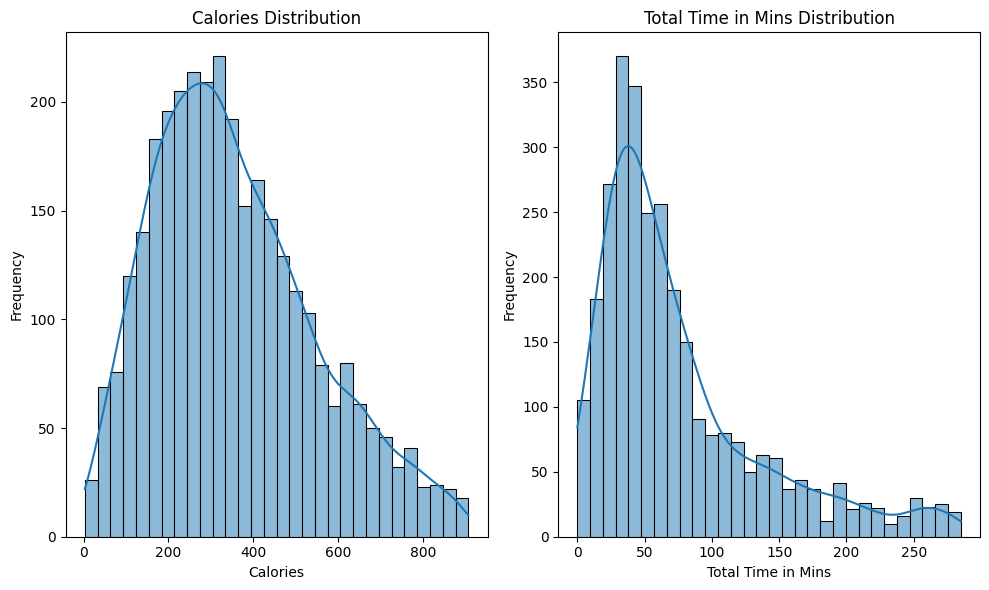

In [10]:
# Exclude outlier from plotting
plt.figure(figsize=(10, 6))

columns = ['Numeric_Calories', 'Total Time in mins']
titles = ['Calories', 'Total Time in Mins']

for i, (column, title) in enumerate(zip(columns, titles), start=1):
    # Calculate numeric values
    column_numeric = pd.to_numeric(recipes_df[column], errors='coerce')
    
    # Define bounds for outliers
    Q1 = column_numeric.quantile(0.25)
    Q3 = column_numeric.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data based on IQR bounds
    filtered_df = recipes_df[(column_numeric >= lower_bound) & (column_numeric <= upper_bound)]
    
    plt.subplot(1, 2, i)
    sns.histplot(filtered_df[column], bins=30, kde=True)
    plt.title(f'{title} Distribution')
    plt.xlabel(title)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

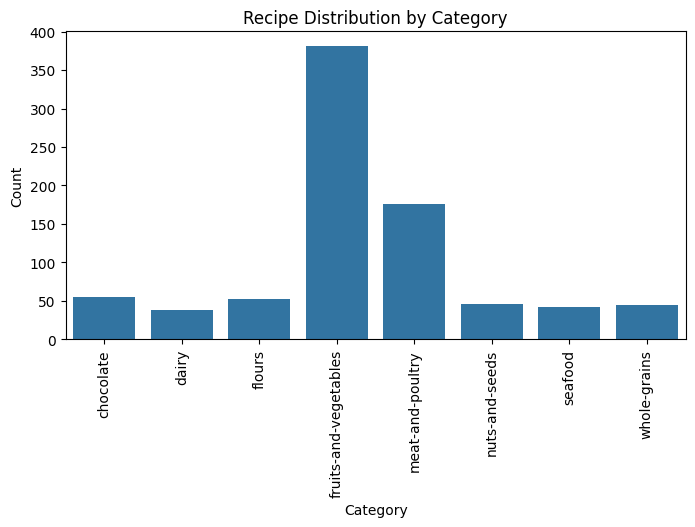

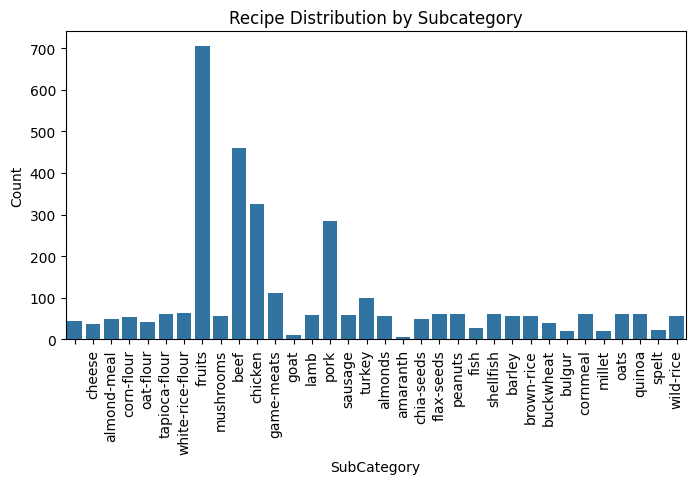

In [11]:
category_df = recipes_df.groupby(['Category', 'SubCategory']).size().reset_index(name='Count')

# plot by Category
plt.figure(figsize=(8, 4))
sns.barplot(x='Category', y='Count', data=category_df, errorbar=None)
plt.xticks(rotation=90)
plt.title('Recipe Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

# plot by SubCategory
plt.figure(figsize=(8, 4))
sns.barplot(x='SubCategory', y='Count', data=category_df, errorbar=None)
plt.xticks(rotation=90)
plt.title('Recipe Distribution by Subcategory')
plt.xlabel('SubCategory')
plt.ylabel('Count')
plt.show()

## Barchart of Top 10 Stopwords

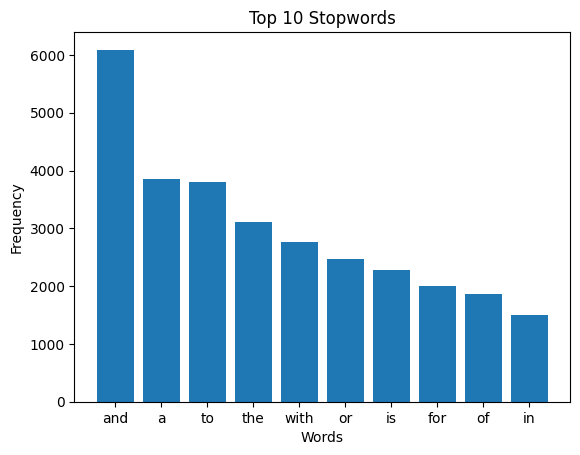

In [12]:
combined_text = recipes_df.apply(lambda row: f"{row['Description']} {row['Ingredients']}", axis=1)
combined_text = combined_text.values.tolist()

sw = stopwords.words("english")

# Flatten series of list into single list of tokens
corpus = [w for word in combined_text for w in word.split()]

sw_dict = defaultdict(int)
for word in corpus:
    if word in sw:
        sw_dict[word]+=1

top_10_stopwords = Counter(sw_dict).most_common(10)

# Extract words and counts
words = [word[0] for word in top_10_stopwords]
counts = [word[1] for word in top_10_stopwords]

# Plotting the top stopwords
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Stopwords')
plt.show()

In [13]:
def descriptive_stats(tokens, num_tokens = 5, verbose=True) :      
    # Given a list of tokens, print number of tokens, number of unique tokens, and number of characters
    tokens = [token for token in tokens if len(token) > 2]

    # Fill in the correct values here. 
    num_tokens_tot = len(tokens)
    num_unique_tokens = len(set(tokens))
    num_characters = sum(
        len(token) for token in tokens)    
    
    # Get lexical diversity (https://en.wikipedia.org/wiki/Lexical_diversity), 
    # and num_tokens,  most common tokens.
    lexical_diversity = num_unique_tokens / num_tokens_tot \
        if num_tokens_tot > 0 else 0.0
    token_counts = Counter(tokens)
    most_common_tokens = token_counts.most_common(num_tokens)

    if verbose :        
        print(f"There are {num_tokens_tot} tokens in the data.")
        print(f"There are {num_unique_tokens} unique tokens in the data.")
        print(f"There are {num_characters} characters in the data.")
        print(f"The lexical diversity is {lexical_diversity:.3f} in the data.")  
        print(f"The {num_tokens} most common tokens are:")
        for token, count in most_common_tokens:
            print(f"{token}: {count}")
        
    # Return a list with the number of tokens, number of unique tokens,
    # lexical diversity, and number of characters, most common tokens
    return [num_tokens_tot, num_unique_tokens, lexical_diversity, \
            num_characters, most_common_tokens]

In [6]:
recipes_df['Desc_Ingre_Direc']  = recipes_df.apply(lambda row: f"{row['Description']} {row['Ingredients']}", axis=1)

In [15]:
# Before Tokenization and Normalization
categories = recipes_df['Category'].unique()
remove_specific_words = ['and', 'the', 'with', 'until','into']

print(f"Token - Description Ingredients Before Tokenization & Normalization")
for category in categories:
    # combine into one string
    category_text = ' '.join(recipes_df[recipes_df['Category'] == category]['Desc_Ingre_Direc'])
    category_tokens = category_text.split()
    category_tokens = [word for word in category_tokens if word not in remove_specific_words]

    print(f"\nCategory: {category}")
    stats = descriptive_stats(category_tokens, num_tokens=5, verbose=True)
    print("-" * 50)

Token - Description Ingredients Before Tokenization & Normalization

Category: dairy
There are 2462 tokens in the data.
There are 880 unique tokens in the data.
There are 14797 characters in the data.
The lexical diversity is 0.357 in the data.
The 5 most common tokens are:
cup: 78
1/2: 68
teaspoon: 51
cheese,: 39
cheese: 35
--------------------------------------------------

Category: flours
There are 15225 tokens in the data.
There are 3113 unique tokens in the data.
There are 90593 characters in the data.
The lexical diversity is 0.204 in the data.
The 5 most common tokens are:
cup: 704
teaspoon: 382
flour,: 244
ounce): 236
cups: 230
--------------------------------------------------

Category: meat-and-poultry
There are 92449 tokens in the data.
There are 8348 unique tokens in the data.
There are 552768 characters in the data.
The lexical diversity is 0.090 in the data.
The 5 most common tokens are:
cup: 2411
teaspoon: 2393
ground: 1629
tablespoons: 1429
tablespoon: 1145
----------

## Tokenization and Normalization

In [7]:
# Defining all functions here

# defining punctuation and stopwords
punctuation = set(punctuation)
sw = stopwords.words("english")

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Removing punctuation
def remove_punctuation(combined_text) :
    return("".join([char for char in combined_text if char not in punctuation]))

# Lower case folding and tokenization (at phrase level)
def tokenize(combined_text) :
    tokens = [token.lower().strip() for token in combined_text.split()]
    
    return(tokens)

# Removing numeric tokens
def remove_numeric(tokens) :
    tokens = [token for token in tokens if token.isalpha()]
    
    return(tokens)

# Extracting lemmatized tokens
def extract_lemmatized_tokens(tokens) :
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return(tokens)

# Removing stopwords
def remove_stopwords(tokens) :
    tokens = [token for token in tokens if token not in sw]
    
    return(tokens)

def prepare(text, pipeline) :
    
    combined_text = f"{text['Description']} {text['Ingredients']}"
    
    tokens = combined_text
    for transform in pipeline :
        tokens = transform(tokens)
    
    return tokens

def prepare_ingredient_tokens(text, pipeline) :

    text = f"{text['Ingredients']}"
    tokens = text
    for transform in pipeline :
        tokens = transform(tokens)

    return tokens

# Function to plot top words
def plot_top_words(model, feature_names, n_top_words, title):
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 12), sharex=True)
    axes = axes.flatten()
    
    for idx, topic in enumerate(model.components_):
        top_words_idx = np.argsort(topic)[-n_top_words:] # Sort the topics and returns the index of top 20 words
        top_words = feature_names[top_words_idx]
        weights = topic[top_words_idx]
        
        ax = axes[idx]
        ax.barh(top_words, weights, height=0.7)
        ax.set_title(f"Topic {idx}", fontdict={"fontsize": 20})
        ax.tick_params(axis="both", which="major", labelsize=15)
        
        # Hides the borders of the plot
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=30)
    plt.show()

In [8]:
# Applying the pipeline techniques

text_pipeline = [remove_punctuation, tokenize, remove_numeric, extract_lemmatized_tokens, remove_stopwords]
recipes_df['Tokens'] = recipes_df.apply(lambda row: prepare(row, pipeline=text_pipeline), axis=1)
recipes_df['num_tokens'] = recipes_df['Tokens'].map(len)
#recipes_df['Ingre_Tokens'] = recipes_df['Ingredients'].apply(lambda row: prepare_ingredient_tokens(row, pipeline=text_pipeline), axis=1)

## Word Clouds 

In [9]:
def wordcloud(word_freq, title=None, max_words=200, stopwords=None):
    
    wc = WordCloud(width=800, height=400,
    background_color= "black", colormap="Paired",
    max_font_size=150, max_words=max_words)
    
    # convert data frame into dict
    if type(word_freq) == pd.Series:
        counter = Counter(word_freq.fillna(0).to_dict())
    else:
        counter = word_freq
        
    # filter stop words in frequency counter
    if stopwords is not None:
        counter = {token:freq for (token, freq) in counter.items()
                   if token not in stopwords}
    wc.generate_from_frequencies(counter)
    
    plt.title(title)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")

def count_words(df, column='Tokens', preprocess=None, min_freq=2):
    
    # process tokens and update counter
    def update(doc):
        tokens = doc if preprocess is None else preprocess(doc)
        counter.update(tokens)
        
    # create counter and run through all data
    counter = Counter()
    df[column].map(update)
    
    # transform counter into data frame
    freq_df = pd.DataFrame.from_dict(counter, orient='index', columns=['freq'])
    freq_df = freq_df.query('freq >= @min_freq')
    freq_df.index.name = 'token'
    
    return freq_df.sort_values('freq', ascending=False)

### Before removing custom stop words

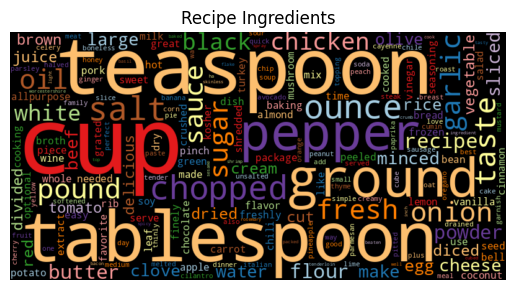

In [19]:
# Word cloud for recipes cleaned data 
recipe_tokens_freq = count_words(recipes_df)
wordcloud(recipe_tokens_freq['freq'], title = "Recipe Ingredients")

From the above word cloud, we can see that more weightage is given to words such as "teaspoon", "cup", and "tablespoon" and these terms could create noise in the corpus. Hence we are removing these terms. Moreover, we are performing lemmatization to convert words such as "cups", teaspoons" etc. to their baseform.

In [10]:
# Creating custom list of stopwords that can add noise to the data
sw_list = ["cup", "teaspoon", "tablespoon", "ounce", "pound", "ground", "salt", "taste"]

def remove_custom_stopwords(tokens) :
    tokens = [token for token in tokens if token not in sw_list]
    
    return(tokens)

def remove_custom_stopwords_ingre(tokens) :
    cleaned_tokens = []
    for token in tokens:
        words = token.split()
        filtered_words = [word for word in words if word not in sw_list]
        cleaned_tokens.append(" ".join(filtered_words))
    return cleaned_tokens

In [11]:
recipes_df['Tokens'] = recipes_df['Tokens'].apply(remove_custom_stopwords)

### After removing custom stop words

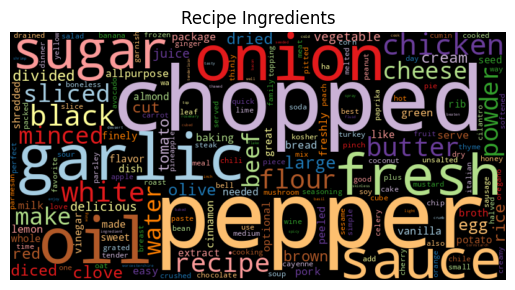

In [22]:
# Word cloud  
recipe_tokens_freq = count_words(recipes_df)
wordcloud(recipe_tokens_freq['freq'], title = "Recipe Ingredients")

## Descriptive Statistics

In [23]:
print(f"Token - Description Ingredients After Tokenization & Normalization")
for category in categories:
    category_tokens = [token for tokens in recipes_df[recipes_df['Category'] == category]['Tokens'] for token in tokens]

    print(f"\nCategory: {category}")   
    stats = descriptive_stats(category_tokens, num_tokens=5, verbose=True)
    print("-" * 50)


Token - Description Ingredients After Tokenization & Normalization

Category: dairy
There are 1737 tokens in the data.
There are 585 unique tokens in the data.
There are 10434 characters in the data.
The lexical diversity is 0.337 in the data.
The 5 most common tokens are:
cheese: 76
chopped: 33
pepper: 33
cream: 26
onion: 21
--------------------------------------------------

Category: flours
There are 10898 tokens in the data.
There are 1897 unique tokens in the data.
There are 63803 characters in the data.
The lexical diversity is 0.174 in the data.
The 5 most common tokens are:
flour: 318
sugar: 191
white: 163
egg: 127
baking: 125
--------------------------------------------------

Category: meat-and-poultry
There are 66106 tokens in the data.
There are 4315 unique tokens in the data.
There are 380029 characters in the data.
The lexical diversity is 0.065 in the data.
The 5 most common tokens are:
pepper: 1573
sauce: 1063
garlic: 1060
chopped: 1011
onion: 992
----------------------

### **Class Imbalance**

In [12]:
recipes_df['Category'].value_counts()

Category
meat-and-poultry         1408
fruits-and-vegetables     762
whole-grains              451
flours                    265
nuts-and-seeds            231
seafood                   125
chocolate                  55
dairy                      38
Name: count, dtype: int64

From the above output, we observe that the meat-and-poultry category has the highest count compared to the other categories, indicating a class imbalance in the dataset. This imbalance can skew the performance of classification models by favoring the dominant class. To address this, we opted not to use the original categories for building the classification model. Instead, we applied topic modeling (LDA, NMF) to generate more balanced and interpretable topics, which we will use as the basis for building our classification models.

## Topic Modeling

### Latent Dirichlet Allocation

In [25]:
# Convert tokens to a string
recipes_df['token_text'] = recipes_df['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Initialize Count Vectorizer
count_text_vectorizer = CountVectorizer(min_df=5,        # removes words less than this threshold
                                        max_df=0.7)       # removes words that appear over 70%

count_text_vectors = count_text_vectorizer.fit_transform(recipes_df['token_text'])
count_text_vectors.shape

(3335, 2121)

In [26]:
# Fitting LDA model
lda_text_model = LatentDirichletAllocation(n_components=8, random_state=314)
W_lda_text_matrix = lda_text_model.fit_transform(count_text_vectors)
H_lda_text_matrix = lda_text_model.components_

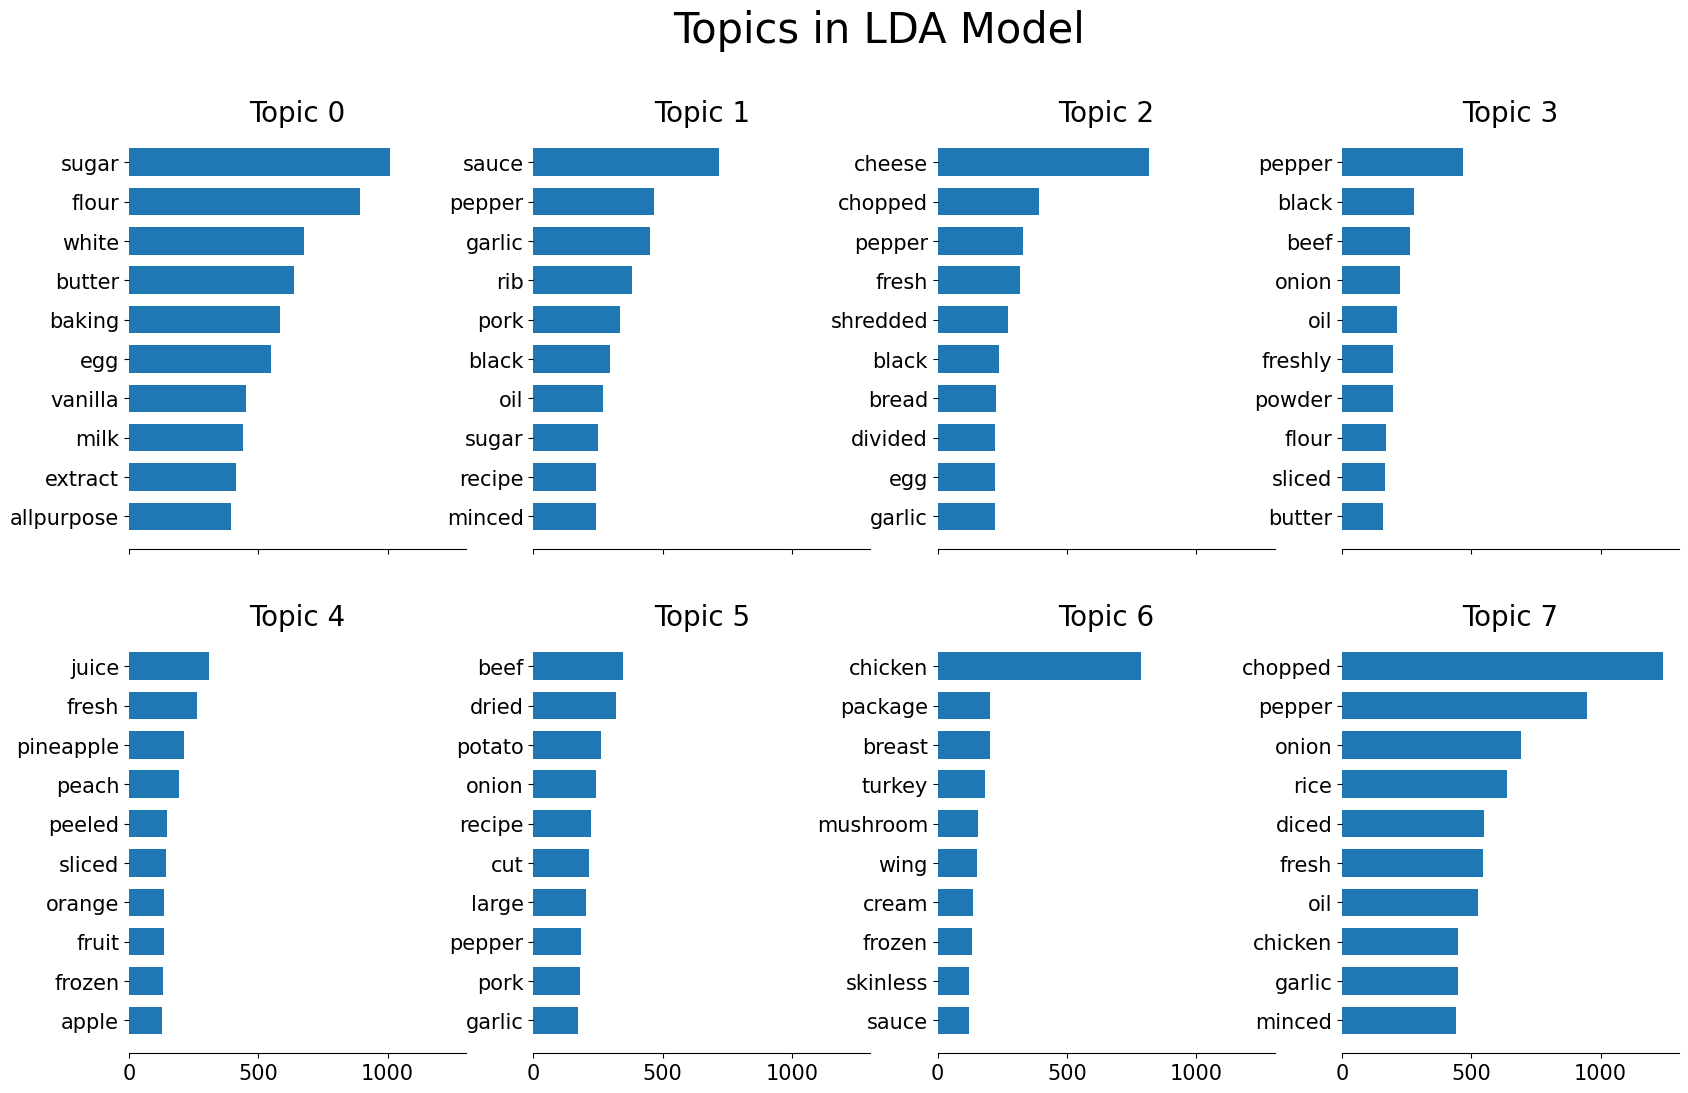

In [27]:
# Plotting the top 10 words
plot_top_words(lda_text_model, count_text_vectorizer.get_feature_names_out(), 10, "Topics in LDA Model")

Based on the results, the topics do not effectively capture distinct themes and show limited differentiation from one another. Therefore, for further analysis, we will restrict the text data to include only nouns.

### Using nouns only

In [13]:
# Function to include nouns only
def include_nouns(tokens) :
    noun_tokens = [token for token, pos in pos_tag(tokens) if pos.startswith('N')]
    
    return(noun_tokens)

# Function to remove verbs
def remove_verbs(tokens):
    tokens = [token for token, pos in pos_tag(tokens) if not pos.startswith('V')]

    return tokens

In [14]:
nouns_data = pd.DataFrame(recipes_df.Tokens.apply(include_nouns))

#recipes_df['Ingre_Tokens'] = recipes_df['Ingre_Tokens'].apply(remove_verbs)

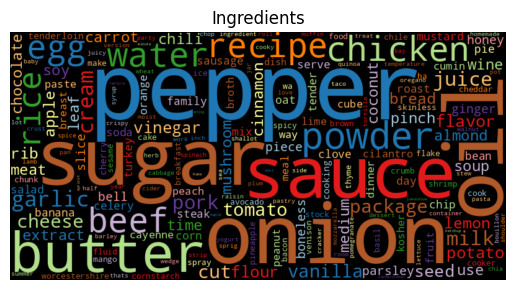

In [30]:
# Word cloud including only nouns
nouns_tokens_freq = count_words(nouns_data)
wordcloud(nouns_tokens_freq['freq'], title = "Ingredients")

In [31]:
# Convert tokens to a string
nouns_data['token_text'] = nouns_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Initialize Count Vectorizer
count_nouns_vectorizer = CountVectorizer(min_df=5,        # removes words less than this threshold
                                        max_df=0.7)       # removes words that appear over 70%

count_nouns_vectors = count_nouns_vectorizer.fit_transform(nouns_data['token_text'])
count_nouns_vectors.shape

(3335, 1194)

### Latent Semantic Analysis (LSA)

In [32]:
# Fitting LSA model with 8 topics
svd_nouns_model = TruncatedSVD(n_components=8, random_state=314)
W_svd_nouns_matrix = svd_nouns_model.fit_transform(count_nouns_vectors)
H_svd_nouns_matrix = svd_nouns_model.components_

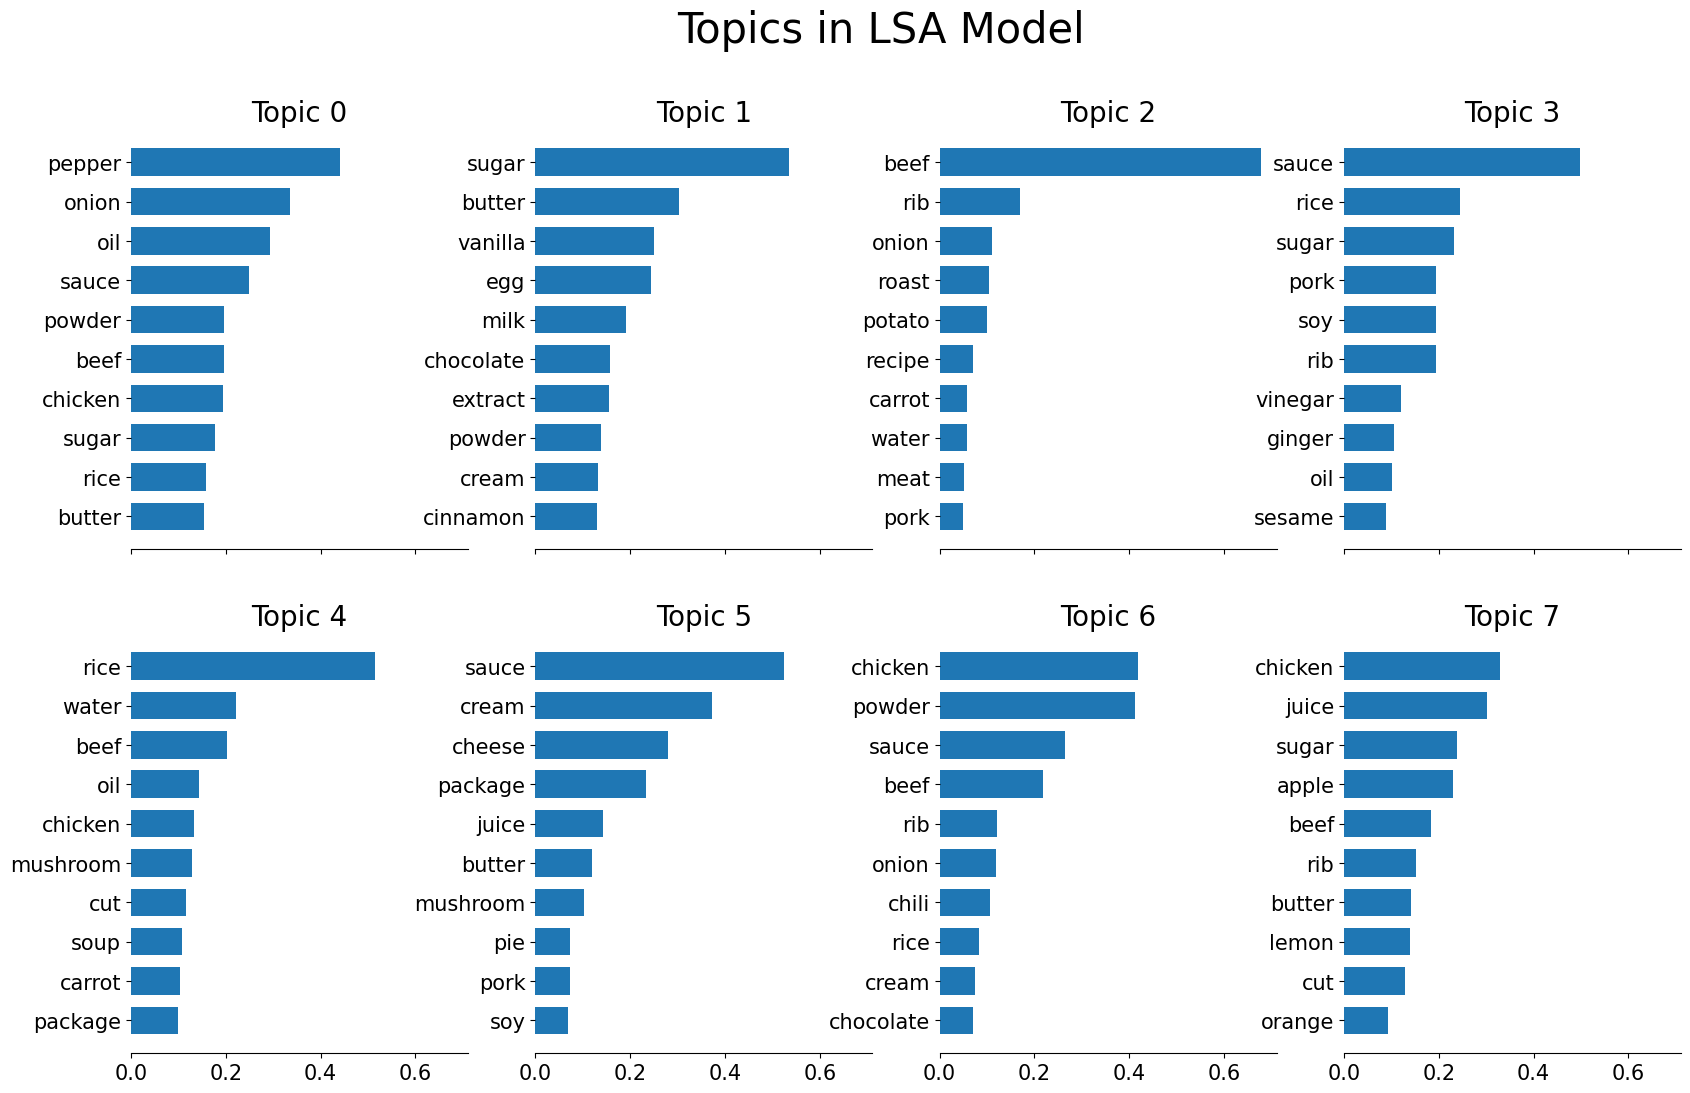

In [33]:
# Plotting the top 10 words
plot_top_words(svd_nouns_model, count_nouns_vectorizer.get_feature_names_out(), 10, "Topics in LSA Model")

The LSA model has effectively grouped terms into coherent topics. For example, Topic 01 brings together baking ingredients like "sugar," "butter," and "vanilla," which are commonly used in desserts, while Topic 02 focuses on meat-based dishes with terms such as "beef," "rib," and "potato." Similarly, Topic 03 captures elements of Asian-style cuisine, featuring terms like "sauce," "rice," "soy," and "pork." Some topics are broader, such as Topic 04, which includes general staples like "rice," "water," "beef," and "chicken," while others, like Topic 07, are more specific, featuring ingredients like "chicken," "juice," and "apple," which suggest nuanced dishes involving sweet and savory combinations.

While the LSA model does effectively group terms into meaningful culinary topics, it tends to blur the boundaries between certain categories due to the overlap of terms across different topics (e.g., "chicken" and "beef" appearing in multiple themes). This could make it less ideal for a platform that requires clear distinctions between broad recipe categories, such as "Asian cuisine" or "desserts."

## Topic Modeling using Gensim

In [15]:
# Convert each token list to a single list of tokens
tokens_list = nouns_data['Tokens'].tolist()

# Creating a Gensim distionary
dict_gensim_tokens = Dictionary(tokens_list)
# Filtering tokens that appear over 70%
dict_gensim_tokens.filter_extremes(no_above=0.7)

# Creating a bag-of-words corpus which returns a list of (token_id, token_count) tuples
bow_gensim_corpus = [dict_gensim_tokens.doc2bow(token) for token in tokens_list]


### **Latent Dirichlet Allocation - LDA**

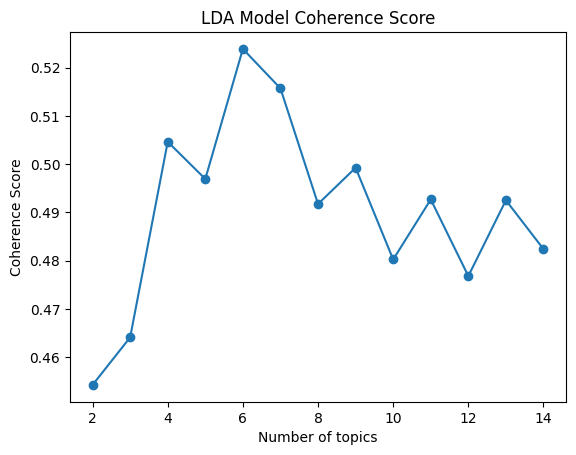

In [16]:
# Finding Optimal number of topics for LDA model
num_topics = np.arange(2, 15)
lda_coherence_vals = []

for num in num_topics :
    lda_gensim_model1 = LdaModel(corpus=bow_gensim_corpus, id2word=dict_gensim_tokens, num_topics=num, 
                                 passes=20, random_state=42)
    lda_coherence = CoherenceModel(model=lda_gensim_model1, texts=tokens_list, 
                                   dictionary=dict_gensim_tokens, coherence='c_v')
    lda_coherence_vals.append(lda_coherence.get_coherence())

# Plotting coherence values
plt.plot(num_topics, lda_coherence_vals, marker='o')
plt.xlabel("Number of topics")
plt.ylabel("Coherence Score")
plt.title("LDA Model Coherence Score")
plt.show()

Based on the output, the highest coherence score was achieved with 6 topics. Therefore, the optimal number of topics is 6 with a coherence score of 0.52.

In [17]:
# LDA Modeling with num_topics=6

lda_gensim_model = LdaModel(corpus=bow_gensim_corpus, id2word=dict_gensim_tokens, num_topics=6, 
                            passes=40, iterations=100, random_state=42)

lda_gensim_model.print_topics()

[(0,
  '0.061*"sugar" + 0.038*"butter" + 0.030*"vanilla" + 0.024*"cream" + 0.022*"chocolate" + 0.020*"juice" + 0.020*"egg" + 0.019*"milk" + 0.017*"extract" + 0.017*"pie"'),
 (1,
  '0.048*"pepper" + 0.036*"onion" + 0.035*"oil" + 0.032*"rice" + 0.031*"sauce" + 0.030*"chicken" + 0.020*"garlic" + 0.019*"powder" + 0.016*"water" + 0.015*"chili"'),
 (2,
  '0.040*"seed" + 0.037*"sugar" + 0.035*"egg" + 0.033*"milk" + 0.031*"oil" + 0.030*"flour" + 0.027*"powder" + 0.021*"banana" + 0.020*"water" + 0.019*"oat"'),
 (3,
  '0.042*"pepper" + 0.032*"oil" + 0.028*"onion" + 0.024*"butter" + 0.023*"chicken" + 0.022*"mushroom" + 0.020*"beef" + 0.019*"garlic" + 0.017*"potato" + 0.015*"wine"'),
 (4,
  '0.054*"cheese" + 0.037*"pepper" + 0.029*"onion" + 0.026*"egg" + 0.022*"sausage" + 0.021*"cream" + 0.021*"turkey" + 0.020*"package" + 0.019*"bread" + 0.018*"sauce"'),
 (5,
  '0.050*"beef" + 0.041*"rib" + 0.038*"sauce" + 0.029*"pork" + 0.029*"pepper" + 0.029*"onion" + 0.027*"powder" + 0.025*"roast" + 0.023*"reci

In [18]:
# Extract top words for each topic
topics = lda_gensim_model.show_topics(formatted=False, num_topics=6, num_words=10)

# Prepare data for plotting
topic_data = []
for topic_num, topic in topics:
    for word, weight in topic:
        topic_data.append([topic_num, word, weight])

# Convert to a DataFrame
lda_topics_df = pd.DataFrame(topic_data, columns=['Topic', 'Word', 'Weight'])

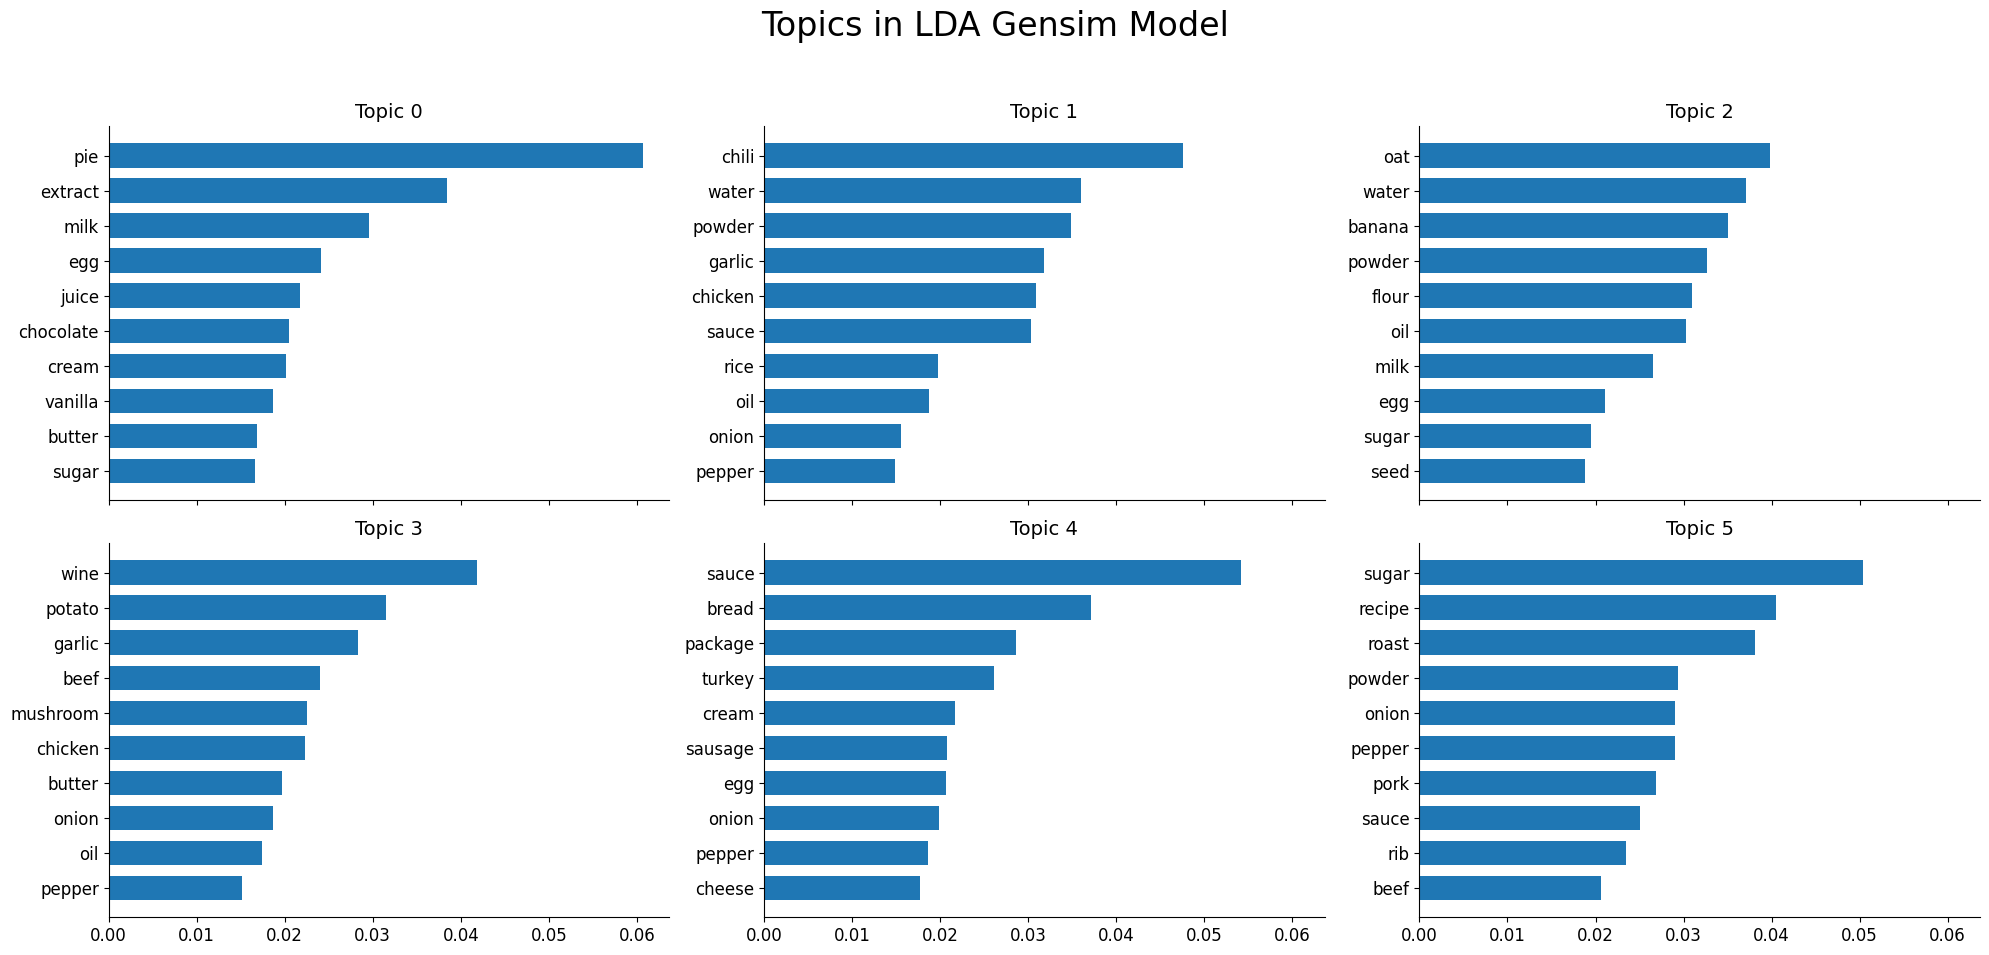

In [19]:
# Create subplots 
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=False)
axes = axes.flatten()

# Plot each topic's top words in its respective subplot
for idx, ax in enumerate(axes):
    # Filter the dataframe for the current topic
    topic_df = lda_topics_df[lda_topics_df['Topic'] == idx]
    
    # Sort words by weight for plotting
    top_words = topic_df['Word'].values
    weights = topic_df['Weight'].sort_values()
    
    # Plot horizontal bar chart for the current topic
    ax.barh(top_words, weights, height=0.7)
    ax.set_title(f"Topic {idx}", fontdict={"fontsize": 14})
    ax.tick_params(axis="both", which="major", labelsize=12)
    
    # Hide the borders of the plot
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# Set the title 
fig.suptitle("Topics in LDA Gensim Model", fontsize=24)

# Adjust layout to fit the subplots 
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Based on the top words for each topic, we can identify distinct themes that differentiate the topics:

+ Topic 0 - **Desserts**
  
  **Keywords** - butter, vanilla, chocolate, egg, milk

+ Topic 1 - **Asian-style**
  
  **Keywords** - rice, onion, sauce, chicken, garlic, oil

+ Topic 2 - **Breakfast foods**
  
  **Keywords** - seed, sugar, egg, oil, flour, banana, milk, bread
  
+ Topic 3 - **Meat-Veggie Combos**
  
  **Keywords** - chicken, mushroom, beef, potato, garlic
  
+ Topic 4 - **Cheese & Creamy dishes**
  
  **Keywords** - cheese, cream, egg, bread, sauce, pepper

+ Topic 5 - **Meat dishes**
  
  **Keywords** -  beef, rib, pork, sauce, roast


### Model Evaluation

In [39]:
# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_gensim_model, texts=tokens_list, dictionary=dict_gensim_tokens, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('Coherence Score: ', coherence_lda)

Coherence Score:  0.5142481099779451


In [40]:
# Topic Visualization
lda_topic_display = pyLDAvis.gensim_models.prepare(lda_gensim_model, corpus=bow_gensim_corpus, 
                                                   dictionary=dict_gensim_tokens, sort_topics=False)
pyLDAvis.display(lda_topic_display)

In the principal component analysis (PCA) diagram, the size of each bubble indicates the prevalence of each topic within the corpus. Topic 2 stands out with a larger bubble, suggesting it is more frequently encountered than the other topics. Topics 1 and 3 are situated close to one another, which indicates some overlap in the terms they encompass. This proximity implies that the recipes or ingredients associated with these topics may be interconnected, possibly reflecting similar culinary styles or ingredient combinations. Conversely, the distinct positions of topics 2, 4, 5, and 6 highlight that they represent unique culinary themes. For instance, Topic 5 seems to focus on cheese and creamy dishes, while Topic 6 appears to center around meat-based meals.

On the right side of the visualization, the graph presents the 30 most salient ingredients for each topic. The blue bars illustrate the overall frequency of each ingredient across the entire corpus, while the red bars depict the contribution of each ingredient to the selected topic. Prominent terms such as "cheese," "sugar," and "beef" suggest they are key components in the recipes. Furthermore, ingredients like "chicken," "rice," and "cream" appear in multiple topics, underscoring their versatility and prevalence across various recipes.

### **Nonnegative Matrix Factorization with Gensim**

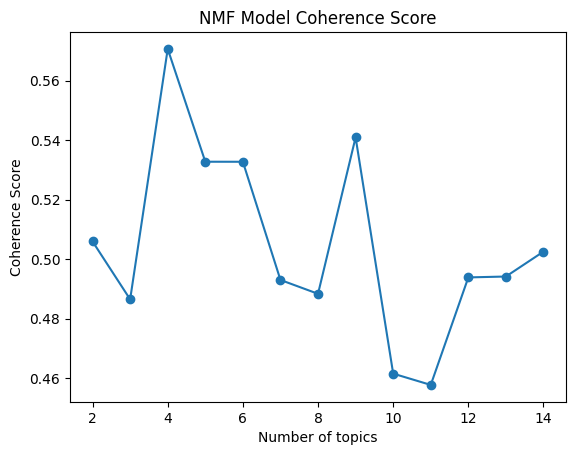

In [39]:
# Finding Optimal number of topics for NMF model
num_topics = np.arange(2, 15)
nmf_coherence_vals = []

for num in num_topics :
    nmf_gensim_model1 = Nmf(bow_gensim_corpus, id2word=dict_gensim_tokens, num_topics=num, 
                            passes=20, random_state=42)
    nmf_coherence = CoherenceModel(model=nmf_gensim_model1, texts=tokens_list, dictionary=dict_gensim_tokens, coherence='c_v')
    nmf_coherence_vals.append(nmf_coherence.get_coherence())

# Plotting coherence values
plt.plot(num_topics, nmf_coherence_vals, marker='o')
plt.xlabel("Number of topics")
plt.ylabel("Coherence Score")
plt.title("NMF Model Coherence Score")
plt.show()

In [40]:
# NMF Modeling with num_topics=4

nmf_gensim_model = Nmf(corpus=bow_gensim_corpus, id2word=dict_gensim_tokens, num_topics=4, passes=20, random_state=42)
nmf_gensim_model.print_topics()

[(0,
  '0.088*"pepper" + 0.056*"chicken" + 0.032*"onion" + 0.032*"powder" + 0.031*"oil" + 0.018*"garlic" + 0.014*"juice" + 0.013*"bell" + 0.013*"sauce" + 0.013*"chili"'),
 (1,
  '0.057*"beef" + 0.049*"sauce" + 0.037*"onion" + 0.034*"oil" + 0.023*"rice" + 0.023*"pepper" + 0.021*"pork" + 0.021*"recipe" + 0.020*"water" + 0.020*"rib"'),
 (2,
  '0.063*"cream" + 0.056*"cheese" + 0.046*"package" + 0.036*"mushroom" + 0.033*"onion" + 0.026*"butter" + 0.022*"soup" + 0.015*"mix" + 0.014*"egg" + 0.013*"cheddar"'),
 (3,
  '0.071*"sugar" + 0.038*"butter" + 0.032*"egg" + 0.029*"vanilla" + 0.029*"powder" + 0.023*"milk" + 0.019*"extract" + 0.018*"chocolate" + 0.018*"cinnamon" + 0.017*"flour"')]

Based on the top words in each topic, we can identify distinct themes. For example, Topic 1, with words like pork, rib, and tenderloin, can be grouped under **Beef and Pork Dishes,** while Topic 3, featuring vanilla, cinnamon, and milk, is suggestive of **Desserts**. Similarly, Topic 2, which includes cream, cheese, onion, mushroom, and soup, points to **Cheese & Creamy dishes.** By analyzing the prominent words, we can similarly classify other topics. The topics here tend to be more specific rather than broader.

### Model Evaluation

In [41]:
# Compute Coherence Score
coherence_nmf_model = CoherenceModel(model=nmf_gensim_model, texts=tokens_list, dictionary=dict_gensim_tokens, coherence='c_v')
coherence_nmf = coherence_nmf_model.get_coherence()
print('Coherence Score: ', coherence_nmf)

Coherence Score:  0.5706958415273431


The coherence score for LDA is 0.514 with 6 topics, while NMF achieves a score of 0.57 with 4 topics. We chose the LDA topic model despite its lower coherence score because it organizes terms into broader, more interpretable categories. Although NMF may yield a higher coherence score by identifying more specific or granular topics, such distinctions can be too narrow for a recipe search platform. In contrast, LDA produces topics that are more aligned with general recipe categories.

In [20]:
# Function to get the dominant topic 
def get_dominant_topic(lda_gensim_model, bow) :
    
    # Get the topic probability for each recipe
    topic_probs = lda_gensim_model.get_document_topics(bow)
    
    # Get the dominant topic that has maximum probability
    dominant_topic = max(topic_probs, key = lambda x: x[1])[0]
    
    return dominant_topic

In [21]:
# Dataframe to hold predicted topics for each recipe
recipe_topics_df = pd.DataFrame()
recipe_topics_df['Title'] = recipes_df['Title']
recipe_topics_df['Tokens'] = nouns_data['Tokens']

# Convert tokens to a string
recipe_topics_df['token_text'] = recipe_topics_df['Tokens'].apply(lambda tokens: ' '.join(tokens))

In [22]:
recipe_topics_df['predicted topic'] = [get_dominant_topic(lda_gensim_model, row) for row in bow_gensim_corpus]

In [23]:
# mapping topic values to each topic
topic_mapping = {0: 'Desserts', 1: 'Asian-style', 2: 'Breakfast foods', 3: 'Meat-veggie combos', 
                 4: 'Cheese & Creamy dishes', 5: 'Meat dishes'}

recipe_topics_df['target topic'] = recipe_topics_df['predicted topic'].map(topic_mapping)

In [24]:
recipe_topics_df.head()

,Title,Tokens,token_text,predicted topic,target topic
0,10 Layer Dip,"[layer, dip, layer, guacamole, cream, cheese, ...",layer dip layer guacamole cream cheese jalapen...,4,Cheese & Creamy dishes
1,1-Dish Taco Bake,"[family, pleaser, ingredientssalsa, taco, corn...",family pleaser ingredientssalsa taco corn chip...,1,Asian-style
2,3-Ingredient Baked BBQ Chicken Wings,"[bbq, sauce, bbq, honey, bbq, love, frozen, ch...",bbq sauce bbq honey bbq love frozen chicken wi...,1,Asian-style
3,3-Ingredient Banana Oatmeal Cookies,"[banana, oatmeal, oat, banana, breakfast, your...",banana oatmeal oat banana breakfast youre lunc...,2,Breakfast foods
4,3-Ingredient Cake Mix Cobbler,"[yummy, peach, cobbler, mix, feel, sunny, day,...",yummy peach cobbler mix feel sunny day peach p...,0,Desserts


In [25]:
recipe_topics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3335 entries, 0 to 3334
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            3335 non-null   object
 1   Tokens           3335 non-null   object
 2   token_text       3335 non-null   object
 3   predicted topic  3335 non-null   int64 
 4   target topic     3335 non-null   object
dtypes: int64(1), object(4)
memory usage: 130.4+ KB


In [ ]:
custom_stopwords = ["cut", "package", "flavor", "recipe", "pinch", "extract", "medium"]

def remove_custom_stopwords2(tokens) :
    tokens = [token for token in tokens if token not in custom_stopwords]
    
    return(tokens)

In [97]:
recipes_df['Ingre_Tokens'] = recipes_df['Ingre_Tokens'].apply(remove_custom_stopwords2)

In [47]:
from collections import Counter

ingredients = [token for sublist in recipe_topics_df['Tokens'] for token in sublist]
ingredient_counts = Counter(ingredients)

# Get the top 30 ingredients
top_30_ingredients = [ingredient for ingredient, count in ingredient_counts.most_common(30)]
top_30_ingredients

['pepper',
 'oil',
 'onion',
 'sugar',
 'sauce',
 'butter',
 'powder',
 'water',
 'chicken',
 'recipe',
 'beef',
 'egg',
 'rice',
 'garlic',
 'cream',
 'juice',
 'milk',
 'pork',
 'cheese',
 'cut',
 'package',
 'tomato',
 'vanilla',
 'flavor',
 'seed',
 'vinegar',
 'potato',
 'flour',
 'mushroom',
 'apple']

In [26]:
category_counts = recipe_topics_df['target topic'].value_counts()
print(category_counts)

target topic
Asian-style               766
Desserts                  726
Meat-veggie combos        671
Cheese & Creamy dishes    420
Breakfast foods           399
Meat dishes               353
Name: count, dtype: int64


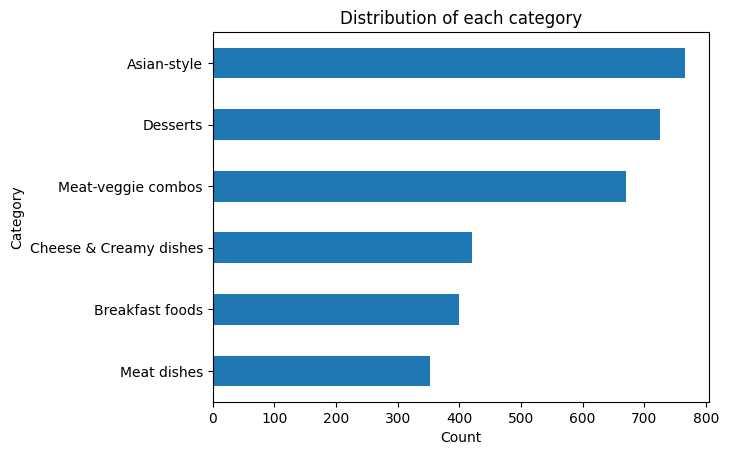

In [27]:
category_counts.sort_values().plot(kind='barh')
plt.title('Distribution of each category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

### Data Partitioning

In [28]:
# Separate predictor and target features
X = recipe_topics_df['token_text']
y = recipe_topics_df['target topic']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert text data to numeric form using TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) 
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

## Model Building with predicted topics

### Logistic Regression

In [29]:
# Training and fitting the model
logit_model = LogisticRegression()
logit_model.fit(X_train_tfidf, y_train)

# Make predictions on test data
logit_y_pred = logit_model.predict(X_test_tfidf)

In [30]:
# Model Evaluation
logit_acc = accuracy_score(y_test, logit_y_pred)
print(f'Model Accuracy: {logit_acc * 100:.2f}%')
print("Classification Report:\n", classification_report(y_test, logit_y_pred))

Model Accuracy: 87.61%
Classification Report:
                         precision    recall  f1-score   support

           Asian-style       0.85      0.91      0.88       251
       Breakfast foods       0.91      0.81      0.86       106
Cheese & Creamy dishes       0.90      0.84      0.87       125
              Desserts       0.92      0.96      0.94       202
           Meat dishes       0.89      0.75      0.81       110
    Meat-veggie combos       0.83      0.87      0.85       207

              accuracy                           0.88      1001
             macro avg       0.88      0.86      0.87      1001
          weighted avg       0.88      0.88      0.88      1001



### Naive Bayes

In [55]:
nb_model = MultinomialNB()

# Training the Naive Bayes model
nb_model.fit(X_train_tfidf, y_train)

# Making predictions on test data
y_pred_nb = nb_model.predict(X_test_tfidf)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Model Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred_nb))

Model Accuracy: 76.02%
                        precision    recall  f1-score   support

           Asian-style       0.68      0.96      0.80       250
       Breakfast foods       0.95      0.55      0.70       105
Cheese & Creamy dishes       0.92      0.43      0.59       125
              Desserts       0.83      0.98      0.90       202
           Meat dishes       0.98      0.36      0.53       111
    Meat-veggie combos       0.68      0.82      0.75       208

              accuracy                           0.76      1001
             macro avg       0.84      0.68      0.71      1001
          weighted avg       0.80      0.76      0.74      1001



In [56]:
# GridSearchCV Hyperparameter Tuning
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0] 
}
grid_search = GridSearchCV(estimator=MultinomialNB(), param_grid=param_grid, cv=8, scoring='accuracy', n_jobs=-1)

# Fit the model with GridSearchCV
grid_search.fit(X_train_tfidf, y_train)

# Get the Best model and parameters
best_nb = grid_search.best_estimator_
print(f'Best alpha value: {grid_search.best_params_["alpha"]}')

# Predict with the tuned model
y_pred_tuned = best_nb.predict(X_test_tfidf)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f'Tuned Model Accuracy: {accuracy_tuned * 100:.2f}%')
print(classification_report(y_test, y_pred_tuned))

Best alpha value: 0.1
Tuned Model Accuracy: 81.82%
                        precision    recall  f1-score   support

           Asian-style       0.77      0.89      0.82       250
       Breakfast foods       0.88      0.77      0.82       105
Cheese & Creamy dishes       0.85      0.65      0.74       125
              Desserts       0.91      0.93      0.92       202
           Meat dishes       0.86      0.68      0.76       111
    Meat-veggie combos       0.74      0.82      0.78       208

              accuracy                           0.82      1001
             macro avg       0.84      0.79      0.81      1001
          weighted avg       0.82      0.82      0.82      1001



### Random Forest

In [57]:
# RF Model
RF_Model = RandomForestClassifier(random_state=42)

# Fitting the model
RF_Model.fit(X_train_tfidf, y_train)

# Use Best RF Model Predict Function
y_pred_RF = RF_Model.predict(X_test_tfidf)

# Evaluate Tuned Model
RF_Accuracy = accuracy_score(y_test, y_pred_RF)
print(f'Random Forest Model: {RF_Accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred_RF))

Random Forest Model: 77.52%
                        precision    recall  f1-score   support

           Asian-style       0.74      0.82      0.78       250
       Breakfast foods       0.91      0.79      0.85       105
Cheese & Creamy dishes       0.82      0.57      0.67       125
              Desserts       0.85      0.95      0.90       202
           Meat dishes       0.81      0.57      0.67       111
    Meat-veggie combos       0.67      0.78      0.72       208

              accuracy                           0.78      1001
             macro avg       0.80      0.75      0.76      1001
          weighted avg       0.78      0.78      0.77      1001



### Neural Networks

In [51]:
# One-hot encoder 
lb = LabelBinarizer()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

# Build the Neural Network
nn_model = Sequential()
nn_model.add(Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)))  # Input layer
nn_model.add(Dense(64, activation='relu'))  # Hidden layer
nn_model.add(Dense(len(lb.classes_), activation='softmax'))  # Output layer

# Compile the model with Adam
nn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
nn_model.fit(X_train_tfidf, y_train_encoded, epochs=10, batch_size=32, verbose=1)

# Make predictions on test data
y_pred_nn_prob = nn_model.predict(X_test_tfidf)
y_pred_nn = lb.inverse_transform(y_pred_nn_prob)  

# Model Evaluation
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f'Neural Network Model Accuracy: {accuracy_nn * 100:.2f}%')
print(classification_report(y_test, y_pred_nn))

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4379 - loss: 1.6847
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7878 - loss: 0.6747
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9805 - loss: 0.1697
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9951 - loss: 0.0593
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0261
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0156
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0101
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0070
Epoch 9/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0050
Epoch 10/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0042
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network Model Accuracy: 87.21%
                        precision    recall  f1-score   support

           Asian-

### Decision Trees

In [59]:
# Training the model
DTmodel = DecisionTreeClassifier(random_state=42)
DTmodel.fit(X_train_tfidf, y_train)

# Making predictions on test data
y_pred_DT = DTmodel.predict(X_test_tfidf)
DT_accuracy = accuracy_score(y_test, y_pred_DT)
print(f'Decision Tree Training Accuracy: {DT_accuracy * 100:.2f}%')

Decision Tree Training Accuracy: 61.94%


**Hyperparameter Tuning**

In [60]:
# Defining parameter grid
param_grid = {
    'max_depth': [10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

DT_grid_search = GridSearchCV(DTmodel, param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Fitting the model
DT_grid_search.fit(X_train_tfidf, y_train)

# best estimator
best_dt = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Predict with the tuned model
y_pred_tuned_dt = best_dt.predict(X_test_tfidf)

# Evaluate the tuned model
DT_tuned_acc = accuracy_score(y_test, y_pred_tuned_dt)
print(f'Tuned Decision Tree Accuracy: {DT_tuned_acc * 100:.2f}%')
print(classification_report(y_test, y_pred_tuned_dt))

Best Parameters: {'alpha': 0.1}
Tuned Decision Tree Accuracy: 81.82%
                        precision    recall  f1-score   support

           Asian-style       0.77      0.89      0.82       250
       Breakfast foods       0.88      0.77      0.82       105
Cheese & Creamy dishes       0.85      0.65      0.74       125
              Desserts       0.91      0.93      0.92       202
           Meat dishes       0.86      0.68      0.76       111
    Meat-veggie combos       0.74      0.82      0.78       208

              accuracy                           0.82      1001
             macro avg       0.84      0.79      0.81      1001
          weighted avg       0.82      0.82      0.82      1001



### K Nearest Neighbor Modeling

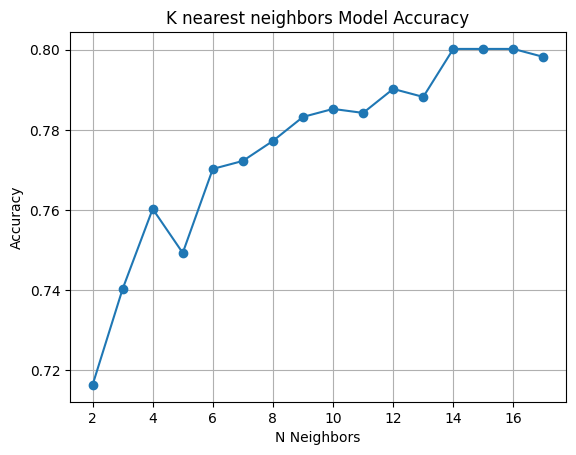

In [61]:
n_neighbors = np.arange(2, 18)
knn_accuracy_scores = []

# Model trained for different values of n neighbors
for n in n_neighbors:
    KNNmodel = KNeighborsClassifier(n_neighbors=n)
    KNNmodel.fit(X_train_tfidf, y_train)
    
    y_pred_knn = KNNmodel.predict(X_test_tfidf)
    knn_acc = accuracy_score(y_test, y_pred_knn)
    knn_accuracy_scores.append(knn_acc)

# Plotting accuracy for different n values
plt.plot(n_neighbors, knn_accuracy_scores, marker='o')
plt.xlabel("N Neighbors")
plt.ylabel("Accuracy")
plt.title("K nearest neighbors Model Accuracy")
plt.grid(True)
plt.show()

In [62]:
# Train using best n_neighbors value
KNNmodel = KNeighborsClassifier(n_neighbors=17)
KNNmodel.fit(X_train_tfidf, y_train)

# Making predictions on test data
best_y_pred_knn = KNNmodel.predict(X_test_tfidf)

# Model Evaluation
knn_best_accuracy = accuracy_score(y_test, best_y_pred_knn)
print("KNN best accuracy: {:.2f}%".format(knn_best_accuracy * 100))
print("Classification Report:\n", classification_report(y_test, best_y_pred_knn))

KNN best accuracy: 79.82%
Classification Report:
                         precision    recall  f1-score   support

           Asian-style       0.76      0.83      0.79       250
       Breakfast foods       0.84      0.81      0.83       105
Cheese & Creamy dishes       0.87      0.68      0.76       125
              Desserts       0.84      0.93      0.88       202
           Meat dishes       0.72      0.75      0.73       111
    Meat-veggie combos       0.79      0.73      0.76       208

              accuracy                           0.80      1001
             macro avg       0.80      0.79      0.79      1001
          weighted avg       0.80      0.80      0.80      1001



## Performance Metrics

In [63]:
# Define Models
models = ['Neural Network', 'Random Forest', 'Logistic Regression', 
          'Tuned Naive Bayes', 'Tuned Decision Tree', 'K-Nearest neighbors']

accuracies = [
    accuracy_nn * 100,
    RF_Accuracy * 100,
    logit_acc * 100,
    accuracy_tuned * 100,
    DT_tuned_acc * 100,
    knn_best_accuracy * 100
]

# Table for performance matrix
performance_df = pd.DataFrame({
    'Model': models,
    'Accuracy (%)': [f'{acc:.2f}%' for acc in accuracies] })

In [64]:
precision = []
recall = []
f1_score = []

for y_pred in [y_pred_nn, y_pred_RF, logit_y_pred, y_pred_tuned, y_pred_tuned_dt, best_y_pred_knn]:
    report = classification_report(y_test, y_pred, output_dict=True)
    precision.append(report['weighted avg']['precision'] * 100)
    recall.append(report['weighted avg']['recall'] * 100)
    f1_score.append(report['weighted avg']['f1-score'] * 100)

# Precision Recall And F1 Score Calculation
performance_df['Precision (%)'] = [f'{prec:.2f}%' for prec in precision]
performance_df['Recall (%)'] = [f'{rec:.2f}%' for rec in recall]
performance_df['F1 Score (%)'] = [f'{f1:.2f}%' for f1 in f1_score]


In [65]:
# ROC AUC probability
logit_y_proba = logit_model.predict_proba(X_test_tfidf)
nb_y_proba = nb_model.predict_proba(X_test_tfidf)
nn_y_proba = nn_model.predict(X_test_tfidf)  
rf_y_proba = RF_Model.predict_proba(X_test_tfidf)
knn_y_prob = KNNmodel.predict_proba(X_test_tfidf)
dt_y_prob = best_dt.predict_proba(X_test_tfidf)

# Get ROC AUC scores
logit_auc = roc_auc_score(y_test, logit_y_proba, multi_class='ovr')
nb_auc = roc_auc_score(y_test, nb_y_proba, multi_class='ovr')
nn_auc = roc_auc_score(y_test, nn_y_proba, multi_class='ovr')  
rf_auc = roc_auc_score(y_test, rf_y_proba, multi_class='ovr')
knn_roc_auc = roc_auc_score(y_test, knn_y_prob, multi_class='ovr')
dt_roc_auc = roc_auc_score(y_test, dt_y_prob, multi_class='ovr')

performance_df['ROC AUC Score'] = [
    f'{nn_auc * 100:.2f}%', 
    f'{rf_auc * 100:.2f}%', 
    f'{logit_auc * 100:.2f}%', 
    f'{nb_auc * 100:.2f}%', 
    f'{dt_roc_auc * 100:.2f}%', 
    f'{knn_roc_auc * 100:.2f}%'
]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [66]:
performance_df

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC AUC Score
0,Neural Network,87.11%,87.16%,87.11%,87.11%,98.70%
1,Random Forest,77.52%,78.27%,77.52%,77.15%,96.29%
2,Logistic Regression,87.51%,87.65%,87.51%,87.42%,98.66%
3,Tuned Naive Bayes,81.82%,82.45%,81.82%,81.63%,98.33%
4,Tuned Decision Tree,81.82%,82.45%,81.82%,81.63%,97.94%
5,K-Nearest neighbors,79.82%,80.03%,79.82%,79.68%,96.62%


In [31]:
import pickle

# Saving model to pickle file
with open("logit_reg.pkl", "wb") as file:
    pickle.dump(logit_model, file)

# # Saving vectorizer to pickle file
# with open("tfidf_vectorizer.pkl", 'wb') as vectorizer_file:
#     pickle.dump(tfidf_vectorizer, vectorizer_file)

In [56]:
import json
with open("ingredients.json", "w") as f:
    f.write(json.dumps(top_30_ingredients))

In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'ADS-509 Peer Evaluation Form.docx', 'ADS-509 Team Project Status Update Form Final.docx', 'allrecipes', 'app.py', 'ingredients.json', 'Natural Solutions Executive Brief.mp4', 'Natural Solutions Executive Brief.pptx', 'Natural Solutions Technical Brief.mp4', 'Natural Solutions Technical Brief.pptx', 'neural_network.pkl', 'RecipesClassification.ipynb', 'RecipesClassification.pdf', 'Technical Presentation Notes.docx', 'templates', 'Web scraping Websites.docx']


## References:

- Albrecht, R. (n.d.). Blueprints for text analysis using python. GitHub. https://github.com/blueprints-for-text-analytics-python/blueprints-text 

- Allrecipes. (2022, September 22). Ingredients A-Z. Allrecipes. https://www.allrecipes.com/ingredients-a-z-6740416 

- Dib, F. (n.d.). Build, test, and debug regex. regex101. https://regex101.com/

- OpenAI. (2024). ChatGPT (October 24 version) [Large language model]. https://chat.openai.com/chat
  
- Beautiful Soup documentation. Beautiful Soup Documentation - Beautiful Soup 4.4.0 documentation. (n.d.). https://beautiful-soup-4.readthedocs.io/en/latest/#navigating-the-tree 
